© Copyright, 2026 G. Schaer.

SPDX-License-Identifier: GPL-3.0-only

# The Single Axis Control Moment Gyroscope Problem

## Introduction

In this project, we are designing a controller to orient a model spacecraft about its yaw axis. To do so, we will be using a ***double-axis control moment gyroscope (CMG)*** comprised of a rolling outer ***gimbal***, a pitching inner gimbal, and a rapidly rotating ***flywheel***. The goal of the project is to determine how to rotate both gimbals so that the spacecraft points in a desired direction. To solve this problem, we are taking an approach called "model-based control". This means that our controller design will be based on a model of the dynamics of the system. The first step, then, is to use the Lagrangian mechanics formulation to derive the equations of motion. This project is similar to the last project in this series, but we have added an additional gimbal. Doing so extends the controllability of the system and allows us to orient objects without relying on a gravity force, like in the single-axis CMG project.

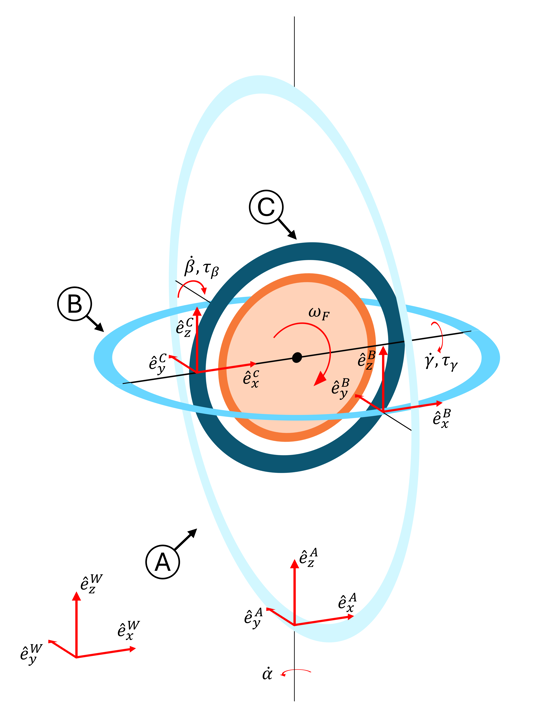

## The Process

To design a model-based controller, we will take 6 steps:
1. Determine the equations of motion of the system
2. Place the equations of motion in standard form
3. Linearize the standard form equations
4. Select a gain matrix that stablizes the system
5. Build a controller with our gain matrix
6. Simulate the system

## 1. System Dynamics and Equations of Motion

Let's derive a dynamic model of the CMG. From the diagram above, we see there are four major components, the spacecraft chassis, called $A$, the outer gimbal, called $B$, the inner gimbal, called $C$, and the flywheel, called $F$. There are three ***generalized coordinates*** for our system: the yaw of the spacecraft chassis, $\alpha$, the roll of the outer gimbal, $\beta$, and the pitch of the inner gimbal, $\gamma$. Additionally, a rolling and pitching torques, $\tau_\beta$ and $\tau_\gamma$, are applied to the outer gimbal and inner gimbals, respectively.

The first step in the Lagrangian mechanics approach to deriving the equations of motion of a system is to calculate the kinetic and potential energies of the system with respect to the generalized coordinates and their derivatives. We can do this using the Python package Sympy.

In [40]:
# Import everything we need from SymPy
import sympy as sym
import numpy as np
from sympy import Symbol, Matrix, Function, Derivative, N
from sympy import diff, simplify, nsimplify, sin, cos, solve, init_printing, symbols, lambdify
init_printing() # This function will make the outputs of SymPy look prettier and be easier to read

Now we are going to define the ***parameters*** of the system, that is, the system constants. All components have thier own moments of inertial: $I_A^A$ for the spacecraft chassis, $I_B^B$ for the outer gimbal, $I_C^C$ for the inner gimbal, and $I_F^C$ for the flywheel. Here, $I_j^k$ denotes the moment of inertia tensor of object $j$ in the inertial frame of object $k$. Additionally, the flywheel is spinning at a constant rotation rate, $\omega_F$.

In [41]:
# Define all the system parameters
omega_F = 157
I_AA = np.array([[0.00828, 0, 0],
                 [0, 0.00828, 0],
                 [0, 0, 0.00828]]) # The moment of inertia of the pendulum in kg-m^2 in its own frame
I_BB = np.array([[0.000476, 0, 0],
                 [0, 0.000937, 0],
                 [0, 0, 0.000476]]) # The moment of inertia of the outer gimbal in kg-m^2 in its own frame
I_CC = np.array([[0.000148, 0, 0],
                 [0, 0.0000777, 0],
                 [0, 0, 0.0000777]]) # The moment of inertia of the inner gimbal in kg-m^2 in its own frame
I_FC = np.array([[0.000164, 0, 0],
                 [0, 0.000235, 0],
                 [0, 0, 0.000164]]) # The moment of inertia of the flywheel in kg-m^2 in the inner gimbal's inertial frame

Now we make symbols and functions. These are elements of SymPy and can be thought of as exactly the same as symbols (variables) and functions from math.

In [42]:
# Time is a symbol (variable)
t = Symbol('t')

# The generalized coordinates and the inputs are both functions of time.
# This means that they are initialized as Functions.
alpha = Function('alpha')
beta = Function('beta')
gamma = Function('gamma')
tau_beta = Function('tau_beta')
tau_gamma = Function('tau_gamma')

Next up, we can start the process of defining the dynamics of the system. We begin by defining the set of rotation matrices that transform one inertial from to another inertial frame. After calculated, in the pursuit of calculating rotational energy, we use these transformation matrices to convert angular rates to angular velocities.

In [43]:
# Define the standard rotation matrices
R_x = lambda x : Matrix([[1, 0,       0     ],
                         [0, cos(x), -sin(x)],
                         [0, sin(x),  cos(x)]])
R_y = lambda x : Matrix([[ cos(x), 0, sin(x)],
                         [ 0,      1, 0     ],
                         [-sin(x), 0, cos(x)]])
R_z = lambda x : Matrix([[cos(x), -sin(x), 0],
                         [sin(x),  cos(x), 0],
                         [0,       0,      1]])

# Calculate the rotation matrices between the adjacent inertial frames
R_AW = R_z(alpha(t))
R_BA = R_y(beta(t))
R_CB = R_x(gamma(t))

In [44]:
# Get the angular velocities of each component in their own inertial frames
ang_vel_A_A = Matrix([0, 0, diff(alpha(t), t)])
ang_vel_B_B = Matrix([0, diff(beta(t), t), 0]) + R_BA.T @ ang_vel_A_A
ang_vel_C_C = Matrix([diff(gamma(t), t), 0, 0]) + R_CB.T @ ang_vel_B_B
ang_vel_F_C = Matrix([0, omega_F, 0]) + ang_vel_C_C

With the angular rates, we can calculate the rotational energies of the system. As well as the ***Langrangian***, which, in this case, is defined as the sum of the rotational energies (because there are not potential energies in this system).

In [45]:
# Get the rotational energies of each component
T_A = 0.5 * (ang_vel_A_A.T @ I_AA @ ang_vel_A_A)[0, 0]
T_B = 0.5 * (ang_vel_B_B.T @ I_BB @ ang_vel_B_B)[0, 0]
T_C = 0.5 * (ang_vel_C_C.T @ I_CC @ ang_vel_C_C)[0, 0]
T_F = 0.5 * (ang_vel_F_C.T @ I_FC @ ang_vel_F_C)[0, 0]

# Calculate the Lagrangian
L = T_A + T_B + T_C + T_F

Given the Lagrangian, the equations of motion of the system are defined via the nonconservative ***Euler-Lagrange equations***:
$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{q_j}} \right) - \frac{\partial L}{\partial q_j} = F_j$$

Where $q_j$ is the $j$th generalized coordinate of the system and $F_j$ is the applied (external) input acting on the $j$th generalized coordinate. For this system, then, the Euler-Lagrange equations take the form:

$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\alpha}} \right) - \frac{\partial L}{\partial \alpha}=0$$
$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\beta}} \right) - \frac{\partial L}{\partial \beta}=\tau_\beta$$
$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\gamma}} \right) - \frac{\partial L}{\partial \gamma}=\tau_\gamma$$

Solving these equations:

In [46]:
# Calculate the Euler-Lagrange equations
f1 = diff(diff(L, Derivative(alpha(t), t)), t) - diff(L, alpha(t))
f2 = diff(diff(L, Derivative(beta(t), t)), t) - diff(L, beta(t)) - tau_beta(t)
f3 = diff(diff(L, Derivative(gamma(t), t)), t) - diff(L, gamma(t)) - tau_gamma(t)

# Solve each equation for the second order derivatives
soln = solve([f1, f2, f3], Derivative(alpha(t), (t, 2)), Derivative(beta(t), (t, 2)), Derivative(gamma(t), (t, 2)))
f_alpha = soln[Derivative(alpha(t), (t, 2))]
f_beta = soln[Derivative(beta(t), (t, 2))]
f_gamma = soln[Derivative(gamma(t), (t, 2))]

# Assemble the second order derivative equations
f = Matrix([f_alpha, f_beta, f_gamma])

# Replace the functions with symbols to make the system look prettier
(alphadot_sym, betadot_sym, gammadot_sym,
 alpha_sym, beta_sym, gamma_sym,
 tau_beta_sym, tau_gamma_sym) = symbols('alphadot, betadot, gammadot, alpha, beta, gamma, tau_beta, tau_gamma')
f = f.subs({Derivative(alpha(t), t) : alphadot_sym,
            Derivative(beta(t), t) : betadot_sym,
            Derivative(gamma(t), t) : gammadot_sym,
            alpha(t) : alpha_sym,
            beta(t) : beta_sym,
            gamma(t) : gamma_sym,
            tau_beta(t) : tau_beta_sym,
            tau_gamma(t) : tau_gamma_sym,})

This gives us our equations of motion, $f$, in the form:
$$
\begin{bmatrix}
\ddot{\alpha} \\
\ddot{\beta} \\
\ddot{\gamma} \\
\end{bmatrix} = f(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma)
$$

## 2. Standard Form

For model-based controls, a ***standard form*** of equations of motion is typically used:
$$
\dot{\mathbf{m}} = f(\mathbf{m}, \mathbf{n}),
$$

where $\mathbf{m}$ is the ***nonlinear state vector*** and $\mathbf{n}$ is the ***nonlinear input vector***.

There are two major differences between our current system and a system in standard form:
1. All the equations in our system are *second order*. Standard form requires all equations to be *first order*.
2. There are dervative arguments in our current system, $f$. Standard form requires that all arguments to $f$ are *zeroth order*. 

To fix problem 1, we need to replace both our *second order* differential equations with two *first order* differential equations. To do this, we can define three new variables: $\omega_{\alpha}$, $\omega_{\beta}$, and $\omega_\gamma$. We define these new variables via the differential equations:
\begin{align}
\dot{\alpha} &= \omega_{\alpha}, \\
\dot{\beta} &= \omega_{\beta},\\
\dot{\gamma} &= \omega_{\gamma}.\\
\end{align}

Now we expand our current system by appending these new differential equations to the end:
$$
\begin{bmatrix}
\ddot{\alpha} \\
\ddot{\beta} \\
\ddot{\gamma} \\
\dot{\alpha} \\ 
\dot{\beta} \\
\dot{\gamma}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\gamma}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
\omega_{\alpha} \\
\omega_{\beta} \\
\omega_{\gamma}
\end{bmatrix}.
$$

Next, by taking a derivative of our new differential equations, we find
\begin{align}
\ddot{\alpha} &= \dot{\omega}_{\alpha}, \\
\ddot{\beta} &= \dot{\omega}_{\beta}, \\
\ddot{\gamma} &= \dot{\omega}_{\gamma}, \\
\end{align}

Therefore, we can replace the second order differential equations with first order differential equations via a change of variables:
$$
\begin{bmatrix}
\dot{\omega_\alpha} \\
\dot{\omega_\beta} \\
\dot{\omega_\gamma} \\
\dot{\alpha} \\ 
\dot{\beta} \\
\dot{\gamma}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\gamma}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
\omega_{\alpha} \\
\omega_{\beta} \\
\omega_{\gamma}
\end{bmatrix}.
$$

This new system is a *first order* system of differential equations, which is what we wanted. To replicate this in code, we can do the following two steps:

In [47]:
# Define our new variables
(omega_alpha_sym, omega_beta_sym, omega_gamma_sym) = sym.symbols('omega_alpha, omega_beta, omega_gamma')

# Append them to the end of the system
f = sym.Matrix([f[0], f[1], f[2], omega_alpha_sym, omega_beta_sym, omega_gamma_sym])

Now we need to fix problem 2: there are dervative arguments in our current system. Standard form requires that all arguments to the system of differential equations are *zeroth order*. The good news is that we already have all the tools we need to correct this problem. To begin, note that the derivative arguments are in the functions
\begin{align}
f_{\alpha}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma), \\
f_{\beta}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma), \\
f_{\gamma}(\dot{\alpha}, \dot{\beta}, \dot{\gamma}, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma).
\end{align}

Recall that we have already created the variables $\omega_{\alpha}$, $\omega_{\beta}$, and $$\omega_{\gamma}$$ which are defined as
\begin{align}
\ddot{\alpha} &= \dot{\omega}_{\alpha}, \\
\ddot{\beta} &= \dot{\omega}_{\beta}, \\
\ddot{\gamma} &= \dot{\omega}_{\gamma}, \\
\end{align}
Therefore, to ensure all arguments to the system are *zeroth order*, we can simply replace every instance of $\dot{\alpha}$ and $\dot{\beta}$ with $\omega_{\alpha}$ and $\omega_{\beta}$, respectively. This results in a system with the form:
$$
\begin{bmatrix}
\dot{\omega_\alpha} \\
\dot{\omega_\beta} \\
\dot{\omega_\gamma} \\
\dot{\alpha} \\ 
\dot{\beta} \\
\dot{\gamma}
\end{bmatrix} =
\begin{bmatrix}
f_{\alpha}(\omega_\alpha, \omega_\beta, \omega_\gamma, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\beta}(\omega_\alpha, \omega_\beta, \omega_\gamma, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
f_{\gamma}(\omega_\alpha, \omega_\beta, \omega_\gamma, \alpha, \beta, \gamma, \tau_\beta, \tau_\gamma) \\
\omega_{\alpha} \\
\omega_{\beta} \\
\omega_{\gamma}
\end{bmatrix}.
$$

Every argument to this system is now *zeroth order*, which is what we wanted. To replicate this in code, we can do the following one step:

In [48]:
# Substitute the derivative terms with the new variables
f = f.subs({alphadot_sym : omega_alpha_sym, betadot_sym : omega_beta_sym, gammadot_sym : omega_gamma_sym})

If we define the nonlinear state vector like this:
$$
\mathbf{m} = 
\begin{bmatrix}
{\omega}_{\alpha} \\
{\omega}_{\beta} \\
{\omega}_{\gamma} \\
{\alpha} \\ 
{\beta} \\
{\gamma}
\end{bmatrix},
$$
and the nonlinear input vector like this:
$$
\mathbf{n} = \begin{bmatrix} \tau_\beta \\ \tau_\gamma \end{bmatrix},
$$
then we can rewrite the system we have created like this:
$$
\dot{\mathbf{m}} = f(\mathbf{m},\mathbf{n})
$$
which is standard form.

## 3. Linearizing the System

Now we want to approximate the nonlinear system dynamics near an equilibrium point by linearizing the system to have the form
$$
\dot{\mathbf{x}} = A\mathbf{x} + B\mathbf{u},
$$
where $\mathbf{x}$ is the ***linear state vector*** and $\mathbf{u}$ is the ***linear input vector***. We call this model ***state space form***. There are three steps we take to convert our current nonlinear, standard form system of equations into state space form:
1. Choose an ***equilibrium point*** towards which the controller will drive the system.
2. Define $\mathbf{x}$ and $\mathbf{u}$.
3. Calculate $A$, also called the ***state matrix***.
4. Calculate $B$, also called the ***input matrix***.

Let's begin by finding an equilibrium point. An equilibrium point is any combination of nonlinear state, $\mathbf{m_{e}}$, and nonlinear input, $\mathbf{n_{e}}$, such that
$$
f(\mathbf{m_{e}}, \mathbf{n_{e}}) = 0.
$$
This is also called a ***stationary point*** because the time derivative of the nonlinear state vector—also called the nonlinear velocity vector—is exactly zero. Remember, we already have $f$, so all we need to do is find a valid $\mathbf{m_{e}}$ and $\mathbf{n_{e}}$. This equilibrium point will be the state that our controller drives the system towards, i.e., if our controller works, as time goes to infinity, the system will go to this equilibrium point. This is called ***stablization***. Accordingly, it would make sense to choose the equilibrium point where no torque is being applied ($\tau_\beta=\tau_\gamma=0$). Let's check to see how this limits the range of possible equilibrium points:

In [49]:
sub_expr = {omega_alpha_sym : 0.0, # To be stationary, all the derivative terms must be 0
            omega_beta_sym : 0.0,  # To be stationary, all the derivative terms must be 0
            omega_gamma_sym : 0.0, # To be stationary, all the derivative terms must be 0
            tau_beta_sym : 0.0,    # We want the torques to be 0 at equilibrium
            tau_gamma_sym : 0.0,}  # We want the torques to be 0 at equilibrium
equil_f = f.evalf(subs=sub_expr)
print('Equilibrium Condition:')
N(equil_f, 3)

Equilibrium Condition:


Evaluating the equations of motion, we find that these constraints guarantee an equilibrium point. This means that, as long as the inputs are 0, we can select any chassis or gimbal angles, $\alpha$, $\beta$, $\gamma$, we like and know we will have found an equilibrium point, i.e.,

\begin{align}
\forall \mathbf{m}_e\in \mathbb{R}^6\quad \text{such}\ \text{that}\quad f(\mathbf{m}_e, \mathbf{0})=\mathbf{0},\\
f(\mathbf{m}_e+\begin{bmatrix}0\\0\\0\\ a \\ b \\ c\end{bmatrix}, \mathbf{0})=\mathbf{0}\quad \forall a,b,c \in \mathbb{R}.
\end{align}

For now, let's select $\beta=\gamma=0$, but leave the chassis yaw, $\alpha$, unconstrained.

In [50]:
equilibrium_point = {omega_alpha_sym : 0.0,
                     omega_beta_sym : 0.0,
                     omega_gamma_sym : 0.0,
                     tau_beta_sym : 0.0,
                     tau_gamma_sym : 0.0,
                     beta_sym : 0.0,
                     gamma_sym : 0.0,} 

Recall, in the previous project in this series we defined 
\begin{align}
\mathbf{x} &= \mathbf{m} - \mathbf{m_{e}}\\
\mathbf{u} &= \mathbf{n} - \mathbf{n_{e}}\\
A &= \left.\frac{\partial f}{\partial \mathbf{m}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}\\
B &= \left.\frac{\partial f}{\partial \mathbf{n}}\right|_{\mathbf{m_{e}}, \mathbf{n_{e}}}.\\
\end{align}
Doing so allows us to approximate our equations of motion $\dot{\mathbf{m}}=f(\mathbf{m},\mathbf{n})$ as
$$
\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u},
$$
which is state space form. This state space representation can then be used to solve a ***linear quadratic problem*** to generate an optimal feedback controller. Let's calculate $A$ and $B$ now.

In [ ]:
# First we define the nonlinear state vector
m = [omega_alpha_sym, omega_beta_sym, omega_gamma_sym, alpha_sym, beta_sym, gamma_sym]

# Then we calculate the Jacobian of f with respect to the nonlinear state vector
A = f.jacobian(m)

# And finally, we evaluate the Jacbobian at the selected equilibrium point
A = A.evalf(subs=equilibrium_point)
print('A=')
N(A,3)

Note that the last three columns of $A$ are $\mathbf{0}$. Because of this, $A$ has the special property that, for all $a,b,c\in\mathbb{R}$,
$A\begin{bmatrix}0\\0\\0\\a\\0\\0\end{bmatrix}=A\begin{bmatrix}0\\0\\0\\0\\b\\0\end{bmatrix}=A\begin{bmatrix}0\\0\\0\\0\\0\\c\end{bmatrix}0$.

In [ ]:
# First we define the nonlinear input vector
n = [tau_beta_sym, tau_gamma_sym]

# Then we calculate the Jacobian of f with respect to the nonlinear input vector
B = f.jacobian(n)

# And finally, we evaluate the Jacbobian at the selected equilibrium point
B = B.evalf(subs=equilibrium_point)
print('B=')
N(B,3)

Note that we did not define an equilibrium value for $\alpha$; however, neither $A$ nor $B$ are dependent on $\alpha$. This means that the linear approximation of the dynamics near $\omega_\alpha=\omega_\beta=\omega_\gamma=\beta=\gamma=\tau_\beta=\tau_\gamma=0$ is independent of the value of $\alpha$, i.e., for a given equilibrium point $(\mathbf{m}_e, \mathbf{n}_e)$, our state space model is just as accurate near $(\mathbf{m}_e, \mathbf{n}_e)$ as it is near the equilibrium point $(\mathbf{m}_e+\begin{bmatrix}0\\0\\0\\ a \\ 0 \\ 0\end{bmatrix}, \mathbf{n}_e)$, $a\in\mathbb{R}$. We showed above that $(\mathbf{m}_e+\begin{bmatrix}0\\0\\0\\ a \\ 0 \\ 0\end{bmatrix}, \mathbf{n}_e)$ is also an equilibrium point.

## 4. Controller Design

### 4a. Controllability

Before starting our controller design, we should ensure that we can actually find a set of control inputs that drive the system to our chosen equilibrium point. Formalizing this statement, we want to ensure that, for all possible pairings of arbitrary initial states, $\mathbf{x_0}$, and terminal states, $\mathbf{x_f}$, there exists a control sequence, $\mathbf{u}(t)$, that drives the system from $\mathbf{x_0}$ to $\mathbf{x_f}$. A dynamic system that statisfies this condition is called a ***controllable*** system.

Consider our state space system $$\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u}.$$
We can determine if it is controllable by investigating its ***controllability matrix***, $\mathcal{C}$:
$$\mathcal{C}=\begin{bmatrix}B&AB&A^2B&\ldots&A^{n-1}B\end{bmatrix},$$
where $n$ is the number of states in the state space system, i.e., the length of the linear state vector, $\mathbf{x}$.

As it turns out, the system is controllable if and only if $\mathcal{C}$ has a valid pseudoinverse. A valid pseudoinverse exists if and only if $\mathcal{C}$ has exactly $n$ nonzero single values. Let's determine if our system is controllable now:

In [ ]:
ctrb = np.hstack((B, A@B, A@A@B, A@A@A@B, A@A@A@A@B, A@A@A@A@A@B)).astype(float)
print('Controllability Matix:')
N(Matrix(ctrb), 3)

In [ ]:
# Get the single value decomposition of C and compare the number of nonzero single values to the number of states
U, s, Vh = np.linalg.svd(ctrb, full_matrices=True)
print("Is Controllable: {}".format(np.count_nonzero(s) >= len(m)))

So we find that our system is controllable, and, as such, we are able to continue with the controller design.

### 4b. Reference Tracking

Suppose we wanted to point our spacecraft at $\alpha=0$ and later at $\alpha=\frac{\pi}{12}$. Were our linear dynamics dependent on $\alpha$, to do this we would need to calculate a set of control gains for the two different equilibrium points and then determine a method of switching between our controllers while maintaining system stability. However, because our linear dynamics are independent of $\alpha$, we can instead utilize a method called ***reference tracking*** to drive our system to any $\alpha$ we want without modifying the controller.

The controllers we have designed so far converge the system to $0$. That is
$$
\mathbf{x}(t) \rightarrow 0\quad \text{as}\quad t \rightarrow \infty.
$$
Suppose instead we want the system to converge to something else. That is
$$
\mathbf{x}(t) \rightarrow \mathbf{x}_{des}=\begin{bmatrix}0\\0\\0\\ a \\ 0 \\ 0\end{bmatrix},\quad a\in\mathbb{R}\quad \text{as}\quad t \rightarrow \infty.
$$

To do this, we can define a new variable $\mathbf{z}=\mathbf{x}-\mathbf{x}_{des}$, and a new control law such that 
$$
\mathbf{u}=-K\mathbf{z}.
$$
Given these changes, let's look at the system dynamics:
\begin{align}
\dot{\mathbf{z}} &= \frac{d}{dt}(\mathbf{x} - \mathbf{x}_{des}) \\
&= \dot{\mathbf{x}} - 0 \\
&= \dot{\mathbf{x}}.
\end{align}

Because we already showed that our state space model is just as accurate near $(\mathbf{m}_e, \mathbf{n}_e)$ as it is near the equilibrium point $(\mathbf{m}_e+\mathbf{x}_{des}, \mathbf{n}_e)$, we know that, even when tracking $\mathbf{x}_{des}$, $\dot{\mathbf{x}}\approx A\mathbf{x}+B\mathbf{u}$. Therefore
\begin{align}
\dot{\mathbf{z}} &= \dot{\mathbf{x}} \\
&\approx A\mathbf{x}+B\mathbf{u} \\
&= A(\mathbf{z}+\mathbf{x}_{des})+B\mathbf{u} \\
&= A\mathbf{z}+B\mathbf{u}+A\mathbf{x}_{des}.
\end{align}

We also already showed that $A$ has the special property that $A\mathbf{x}_{des}=0$, therefore
\begin{align}
\dot{\mathbf{z}} &= A\mathbf{z}+B\mathbf{u}+A\mathbf{x}_{des} \\
&= A\mathbf{z}+B\mathbf{u}. \\
\end{align}

By our selected control law $\mathbf{u}=-K\mathbf{z}$, we have
\begin{align}
\dot{\mathbf{z}} &= A\mathbf{z}+B\mathbf{u} \\
&= A\mathbf{z}+B(-K\mathbf{z}) \\
&= (A-BK)\mathbf{z}.
\end{align}

We recognize this ***closed loop response matrix***, $A-BK$, as the same one from the previous pendulum cart series. As such, we have already shown that this system is ***asymptotically stable***, i.e. $\mathbf{z} \rightarrow \mathbf{0}$ as $t \rightarrow \infty$, as long as the real parts of the eigenvalues of the closed loop response matrix are negative. We have also developed methods of calculating the gain matrix $K$ to ensure this condition. Therefore, we know we can build a system such that
$$
\mathbf{z}(t) \rightarrow 0\quad \text{as}\quad t \rightarrow \infty.
$$
Recalling the definition of $\mathbf{z}$, this is identical to the statement:
$$
\mathbf{x}(t) \rightarrow \mathbf{x}_{des}\quad \text{as}\quad t \rightarrow \infty,
$$
which is exactly what we wanted.

Summarizing, we showed that if the following conditions are met:
1. Our state space model, $(A, B)$, is just as accurate near $(\mathbf{m}_e, \mathbf{n}_e)$ as it is near the equilibrium point $(\mathbf{m}_e+\mathbf{x}_{des}, \mathbf{n}_e)$ and
2. $A\mathbf{x}_{des}=0$,

the control law
$$
\mathbf{u}=-K(\mathbf{x}-\mathbf{x}_{des})
$$
results in the system behavior:
$$
\mathbf{x}(t) \rightarrow \mathbf{x}_{des}\quad \text{as}\quad t \rightarrow \infty,
$$
when the real parts of the eigenvalues of $A-BK$ are all negative.

### 4c. Implementing the Controller

We can now design and implement a controller for our system. In the Pendulum Cart series, we learned how to design and solve a ***Linear Quadratic Problem*** for our state space model to find an optimal controller, called a ***Linear Quadratic Regulator***. Repeating this process now, and again using ***Bryson's Rule*** to select an untuned ***state cost matrix, $Q$*** and untuned ***input cost matrix, $R$***, we find the following set of optimal control gains:

Optimal Gain Matrix:


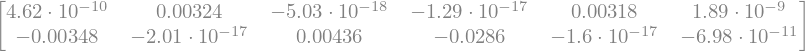

In [16]:
# Import the scipy package that solve the CARE
from scipy.linalg import solve_continuous_are

# Define the state and input cost matrices
Q = np.array([[8.21, 0., 0., 0., 0., 0.],
              [0., 0.101, 0., 0., 0., 0.],
              [0., 0., 0.405, 0., 0., 0.],
              [0., 0., 0., 32.8, 0., 0.],
              [0., 0., 0., 0., 0.405, 0.],
              [0., 0., 0., 0., 0., 1.62]])
R = np.array([[4e4, 0.0],
              [0.0, 4e4]])

# Solve the CARE and calculate the gain matrix
P = solve_continuous_are(np.array(A, dtype=float), np.array(B, dtype=float), Q, R)
K = np.linalg.inv(R)@B.T@P
print("Optimal Gain Matrix:")
N(K,3)

The next step is to test our controller in simulation. This project series's provided simulation function expects us to implement a controller function that takes as argument the nonlinear state of the system, $\mathbf{m}$, and some desired yaw angle, $\alpha_{des}$, and return the torques applied to the gimbals, $\tau_\beta$ and $\tau_\gamma$. Implementing this in code:

In [18]:
def controller(state, alpha_des):
    """
    The controller function. Given some state information and a target yaw angle, calculates torques to apply to the gimbal joints that
    (hopefully) points the spacecraft in the desired direction.

    Parameters
    ----------
    state : dictionary of floats with the following keys
        omega_alpha : float
            The angular rate of the chassis yaw in radians / second.
        omega_beta : float
            The angular rate of the outer gimbal in radians / second.
        omega_gamma : float
            The angular rate of the inner gimbal in radians / second.
        alpha : float
            The yaw angle of the chassis in radians.
        beta : float
            The roll angle of the outer gimbal in radians.
        gamma : float
            The pitch angle of the inner gimbal in radians.
    alpha_des : float
        The target yaw angle of the chassis in radians

    Returns
    -------
    tau_beta : float
        The torque to apply to the outer gimbal joint
    tau_gamma : float
        The torque to apply to the inner gimbal joint
    """
    m_e = np.array([0, 0, 0, 0, 0, 0]) # The equilibrium nonlinear state vector
    n_e = np.array([0, 0])             # The equilibrium nonlinear input vector

    # Define a desired alpha angle
    x_des = np.array([0, 0, 0, alpha_des, 0, 0]) - m_e

    # Build the nonlinear state vector
    m = np.array([state['omega_alpha'], state['omega_beta'], state['omega_gamma'], state['alpha'], state['beta'], state['gamma']])

    # Build the linear state vector
    x = m - m_e

    # Build the reference tracking linear state vector
    z = x - x_des

    # Apply the feedback control law with our selected gain matrix to get the linear input vector
    u = -K@z

    # Convert the linear input vector into the nonlinear input vector
    n = u + n_e

    # Return the nonlinear torques as scalars
    tau_beta = n[0]
    tau_gamma = n[1]
    return tau_beta, tau_gamma

## 5. Running a Simulation

The backend for the simulation has already been made for you. The backend will handle building the simulation environment, running and visualizing the simulation, applying your controller's inputs, and tracking relevant data. Let's import this backend now. It is a function named `run` that is stored in a Python script named `dacmg.py`. 

In [20]:
# Import the project's backend.
from dacmg import run

Now we are ready to run the simulation and collect data. To do this, we simply call the `run` function as pass as arguments the desired program number and the controller function we just built. The program number is an integer that selects which of the desired yaw programs will be run. Each program gives a different sequence of desired yaws as a function of time. The valid program numbers are 1-12. 1-3 are step programs, i.e., at t=2 seconds, the desired alpha instantaneously steps up to a new value. 4-6 are sequential step programs, i.e, every n seconds, the desired alpha instantaneously steps up to a new value. 7-9 are linear ramp programs, i.e., the desired alpha is a linear function of time. 10-12 are sinusoidal programs, i.e. the desired alpha follows a sine function.

Once called, the simulation will automatically run, give a sequence of desired alphas dependent on the program number, apply our controller, and return some data collected during simulation. The returned data is a dictionary with the values:

`data['time']` : list of n floats

    The time, in seconds, at which each data point is collected
    
`data['omega_alpha']` : list of n floats

    The angular rate of the spacecraft, in radians per second, at each of the n data collection points.
    
`data['omega_beta']` : list of n floats

    The angular rate of the outer gimbal, in radians per second, at each of the n data collection points.

`data['omega_gamma']` : list of n floats

    The angular rate of the inner gimbal, in radians per second, at each of the n data collection points.

`data['alpha']` : list of n floats

    The yaw angle of the spacecraft, in radians, at each of the n data collection points.
    
`data['beta']`: list of n floats

    The roll angle of the outer gimbal, in radians, at each of the n data collection points.

`data['gamma']`: list of n floats

    The pitch angle of the inner gimbal, in radians, at each of the n data collection points.

`data['tau_beta']` : list of n floats

    The torque applied to the outer gimbal, in Newton-meters, at each of the n data collection points.

`data['tau_gamma']` : list of n floats

    The torque applied to the inner gimbal, in Newton-meters, at each of the n data collection points.

`data['alpha_des']` : list of n floats

    The desired yaw angle of the spacecraft, in radians, at each of the n data collection points.

In [28]:
# Run the simulation with program number 1 and collect the simulation data
data = run(1, controller)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7004/static/


Voila! Again our controller successfully drives the system to the desired yaw and stays there. We can confirm the by plotting the results:

In [29]:
# Import plotting tool
import matplotlib.pyplot as plt
%matplotlib inline

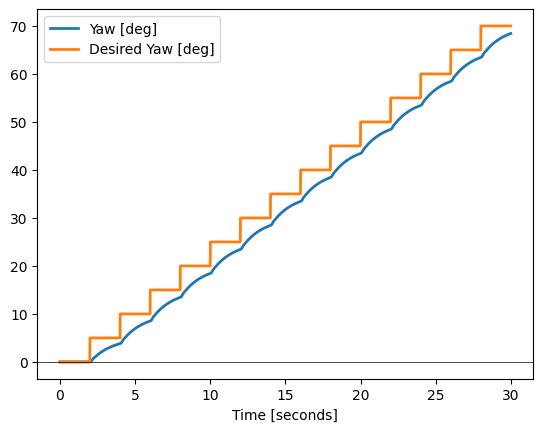

In [30]:
# Plot the error, derivative of the error, and torque as function of time 
plt.plot(data['time'], data['alpha']*180/3.14, label='Yaw [deg]', lw=2.0) 
plt.plot(data['time'], data['alpha_des']*180/3.14, label='Desired Yaw [deg]', lw=2.0) 
plt.legend()
plt.xlabel('Time [seconds]')
plt.axhline(c='k', lw=0.5)
plt.show()

## Assignment